In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import qmc
import time

n_train_points = 5000
n_train_points_bc = 3000
n_train_points_ic = 1500
w_pde, w_bc, w_ic = 1, 1, 1
num_epochs = 2000
t_max = 10
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

L_star = 2 * np.pi
T_star = t_max
U_star = 1.0
Fo = T_star / (L_star ** 2)

b = 0.05
sources = [
    (0.3, 0.7, 10.0),
    (0.7, 0.3, 10.0)
]

In [2]:
def source_term(x, y):
    q = torch.zeros_like(x)
    for x_s, y_s, A in sources:
        q += A * torch.exp(-((x - x_s)**2 + (y - y_s)**2) / (2 * b**2))
    return q


In [3]:
class HeatNet2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(3, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 1)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        return self.layers(inputs)


In [4]:
def generate_training_points():
    sobol_3d = qmc.Sobol(d=3, scramble=True)
    n_sobol = 2 ** int(np.ceil(np.log2(n_train_points)))
    sobol_points = sobol_3d.random(n_sobol)[:n_train_points]

    x_random = torch.FloatTensor(sobol_points[:, 0:1])
    y_random = torch.FloatTensor(sobol_points[:, 1:2])
    t_random = torch.FloatTensor(sobol_points[:, 2:3])

    n_per_boundary = n_train_points_bc // 4
    sobol_2d = qmc.Sobol(d=2, scramble=True)
    n_sobol_2d = 2 ** int(np.ceil(np.log2(n_per_boundary)))
    surface_points = sobol_2d.random(n_sobol_2d)[:n_per_boundary]

    # Грань 1: x = 0, u = 1
    x_left = torch.zeros(n_per_boundary, 1)
    y_left = torch.FloatTensor(surface_points[:, 0:1])
    t_left = torch.FloatTensor(surface_points[:, 1:2])
    u_left = torch.ones(n_per_boundary, 1)

    # Грань 2: x = 1, u = -1
    x_right = torch.ones(n_per_boundary, 1)
    y_right = torch.FloatTensor(surface_points[:, 0:1])
    t_right = torch.FloatTensor(surface_points[:, 1:2])
    u_right = -torch.ones(n_per_boundary, 1)

    # Грань 3: y = 0, u = -1
    x_bottom = torch.FloatTensor(surface_points[:, 0:1])
    y_bottom = torch.zeros(n_per_boundary, 1)
    t_bottom = torch.FloatTensor(surface_points[:, 1:2])
    u_bottom = -torch.ones(n_per_boundary, 1)

    # Грань 4: y = 1, u = 1
    x_top = torch.FloatTensor(surface_points[:, 0:1])
    y_top = torch.ones(n_per_boundary, 1)
    t_top = torch.FloatTensor(surface_points[:, 1:2])
    u_top = torch.ones(n_per_boundary, 1)

    x_boundary = torch.cat([x_left, x_right, x_bottom, x_top], dim=0)
    y_boundary = torch.cat([y_left, y_right, y_bottom, y_top], dim=0)
    t_boundary = torch.cat([t_left, t_right, t_bottom, t_top], dim=0)
    u_boundary = torch.cat([u_left, u_right, u_bottom, u_top], dim=0)

    sobol_2d_ic = qmc.Sobol(d=2, scramble=True)
    n_sobol_ic = 2 ** int(np.ceil(np.log2(n_train_points_ic)))
    ic_points = sobol_2d_ic.random(n_sobol_ic)[:n_train_points_ic]

    x_initial = torch.FloatTensor(ic_points[:, 0:1])
    y_initial = torch.FloatTensor(ic_points[:, 1:2])
    t_initial = torch.zeros(n_train_points_ic, 1)
    u_initial = torch.zeros(n_train_points_ic, 1)

    return {
        'pde': (x_random, y_random, t_random),
        'boundary': (x_boundary, y_boundary, t_boundary, u_boundary),
        'initial': (x_initial, y_initial, t_initial, u_initial)
    }


In [5]:
def compute_derivatives(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, y, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                              create_graph=True, retain_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                               create_graph=True, retain_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u),
                              create_graph=True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y),
                               create_graph=True, retain_graph=True)[0]
    return u_t, u_xx, u_yy


In [6]:
def compute_loss(model, data, batch_size=512):
    total_pde, total_bc, total_ic = [], [], []

    x_random, y_random, t_random = data['pde']
    for i in range(0, len(x_random), batch_size):
        x_batch = x_random[i:i+batch_size]
        y_batch = y_random[i:i+batch_size]
        t_batch = t_random[i:i+batch_size]
        u_t, u_xx, u_yy = compute_derivatives(model, x_batch, y_batch, t_batch)
        q_batch = source_term(x_batch, y_batch)
        residual = u_t - Fo * (u_xx + u_yy) - q_batch
        total_pde.append(torch.mean(residual ** 2))

    x_boundary, y_boundary, t_boundary, u_boundary_true = data['boundary']
    for i in range(0, len(x_boundary), batch_size):
        x_batch = x_boundary[i:i+batch_size]
        y_batch = y_boundary[i:i+batch_size]
        t_batch = t_boundary[i:i+batch_size]
        u_true_batch = u_boundary_true[i:i+batch_size]
        u_pred_batch = model(x_batch, y_batch, t_batch)
        total_bc.append(torch.mean((u_pred_batch - u_true_batch) ** 2))

    x_initial, y_initial, t_initial, u_initial_true = data['initial']
    for i in range(0, len(x_initial), batch_size):
        x_batch = x_initial[i:i+batch_size]
        y_batch = y_initial[i:i+batch_size]
        t_batch = t_initial[i:i+batch_size]
        u_true_batch = u_initial_true[i:i+batch_size]
        u_pred_batch = model(x_batch, y_batch, t_batch)
        total_ic.append(torch.mean((u_pred_batch - u_true_batch) ** 2))

    pde_error = torch.mean(torch.stack(total_pde))
    bc_error = torch.mean(torch.stack(total_bc))
    ic_error = torch.mean(torch.stack(total_ic))
    total_loss = w_pde * pde_error + w_bc * bc_error + w_ic * ic_error
    return total_loss, pde_error, bc_error, ic_error


In [7]:
def train_model():
    model = HeatNet2D()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=500,
        threshold=1e-4, min_lr=1e-6, verbose=True
    )

    data = generate_training_points()
    losses = {'pde': [], 'bc': [], 'ic': [], 'total': [], 'lr': []}

    print("2D PINN для уравнения теплопроводности с точечными источниками")
    print(f"Безразмерные масштабы: L*={L_star:.2f}, T*={T_star:.2f}, U*={U_star:.2f}")
    print(f"Число Фурье Fo = {Fo:.6f}")
    print(f"Источники: {sources}")
    print(f"Радиус источника b = {b}")
    print(f"Точки: PDE={n_train_points}, BC={n_train_points_bc}, IC={n_train_points_ic}")
    print(f"Веса: w_pde={w_pde}, w_bc={w_bc}, w_ic={w_ic}")

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        total, pde, bc, ic = compute_loss(model, data)
        total.backward()
        optimizer.step()
        scheduler.step(total.item())

        losses['pde'].append(pde.item())
        losses['bc'].append(bc.item())
        losses['ic'].append(ic.item())
        losses['total'].append(total.item())
        losses['lr'].append(optimizer.param_groups[0]['lr'])

        if epoch % 1000 == 0:
            print(f"Эпоха {epoch:5d}: Total={total.item():.6f}, "
                  f"PDE={pde.item():.6f}, BC={bc.item():.6f}, IC={ic.item():.6f}, lr={optimizer.param_groups[0]['lr']}")

    return model, data, losses

In [8]:
def plot_training(losses):
    plt.figure(figsize=(15, 5))
    epochs = range(len(losses['total']))
    plt.semilogy(epochs, [w_pde * val for val in losses['pde']],
                 'r-', label=f'PDE × {w_pde}', alpha=0.7, linewidth=2)
    plt.semilogy(epochs, [w_bc * val for val in losses['bc']],
                 'b-', label=f'BC × {w_bc}', alpha=0.7, linewidth=2)
    plt.semilogy(epochs, [w_ic * val for val in losses['ic']],
                 'g-', label=f'IC × {w_ic}', alpha=0.7, linewidth=2)
    plt.semilogy(epochs, losses['total'],
                 'k-', label='Total Loss', linewidth=2)
    plt.title(f'Обучение с источниками (Fo={Fo:.4f})')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss (log scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [9]:
def plot_solution(model):
    n_points = 50
    x = torch.linspace(0, 1, n_points)
    y = torch.linspace(0, 1, n_points)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    times = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]  # размерные

    #глобальные макс и мин
    vmin, vmax = float('inf'), float('-inf')
    all_predictions = []

    for t_val in times:
        T_nd = torch.ones_like(X) * (t_val / T_star)
        X_flat = X.reshape(-1, 1)
        Y_flat = Y.reshape(-1, 1)
        T_flat = T_nd.reshape(-1, 1)

        with torch.no_grad():
            u_pred_nd = model(X_flat, Y_flat, T_flat).reshape(n_points, n_points).numpy()
        u_pred = u_pred_nd * U_star
        all_predictions.append(u_pred)

        vmin = min(vmin, u_pred.min())
        vmax = max(vmax, u_pred.max())

    # отступ
    vmin = vmin - 0.05 * (vmax - vmin)
    vmax = vmax + 0.05 * (vmax - vmin)

    #второй проход
    fig, axes = plt.subplots(1, 7, figsize=(24, 5))

    for idx, (t_val, u_pred) in enumerate(zip(times, all_predictions)):
        im = axes[idx].contourf(X.numpy(), Y.numpy(), u_pred,
                                levels=50, cmap='RdBu_r',
                                vmin=vmin, vmax=vmax)
        axes[idx].set_title(f't = {t_val:.1f} c')
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('y')
        axes[idx].set_aspect('equal')

    # одна общая цветовая шкала для всех графиков
    plt.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.1)
    plt.suptitle('Решение с двумя точечными источниками')
    plt.tight_layout()
    plt.show()

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


2D PINN для уравнения теплопроводности с точечными источниками
Безразмерные масштабы: L*=6.28, T*=10.00, U*=1.00
Число Фурье Fo = 0.253303
Источники: [(0.3, 0.7, 10.0), (0.7, 0.3, 10.0)]
Радиус источника b = 0.05
Точки: PDE=5000, BC=3000, IC=1500
Веса: w_pde=1, w_bc=1, w_ic=1
Эпоха     0: Total=2.587481, PDE=1.521010, BC=1.054610, IC=0.011862, lr=0.001


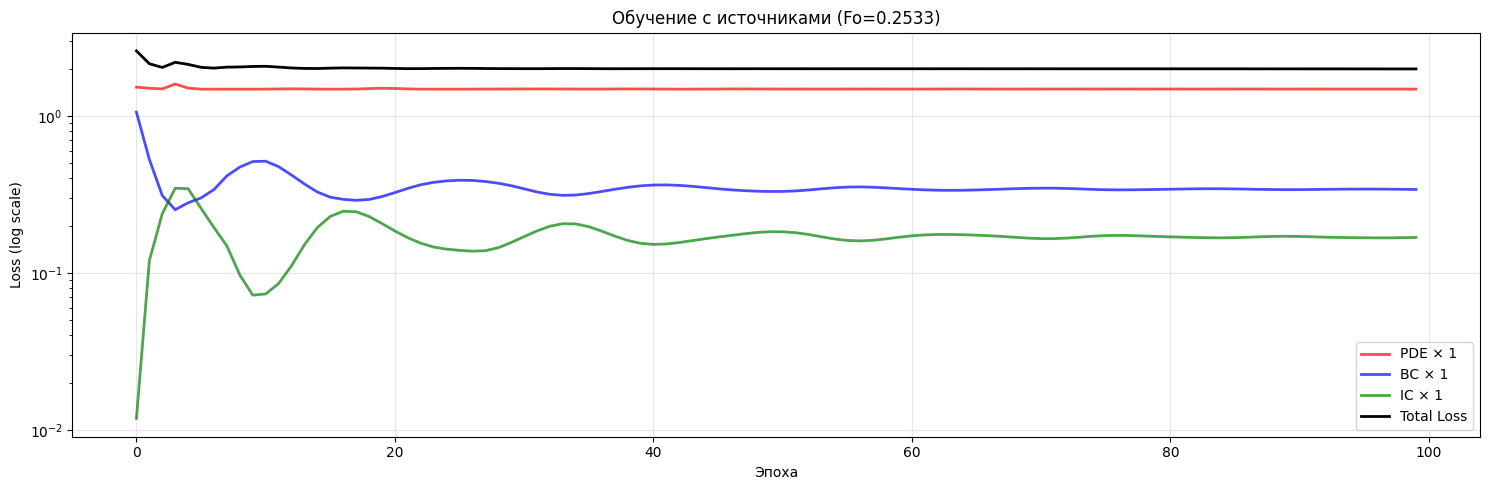

C:\Users\user\AppData\Local\Temp\ipykernel_19116\1728732704.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


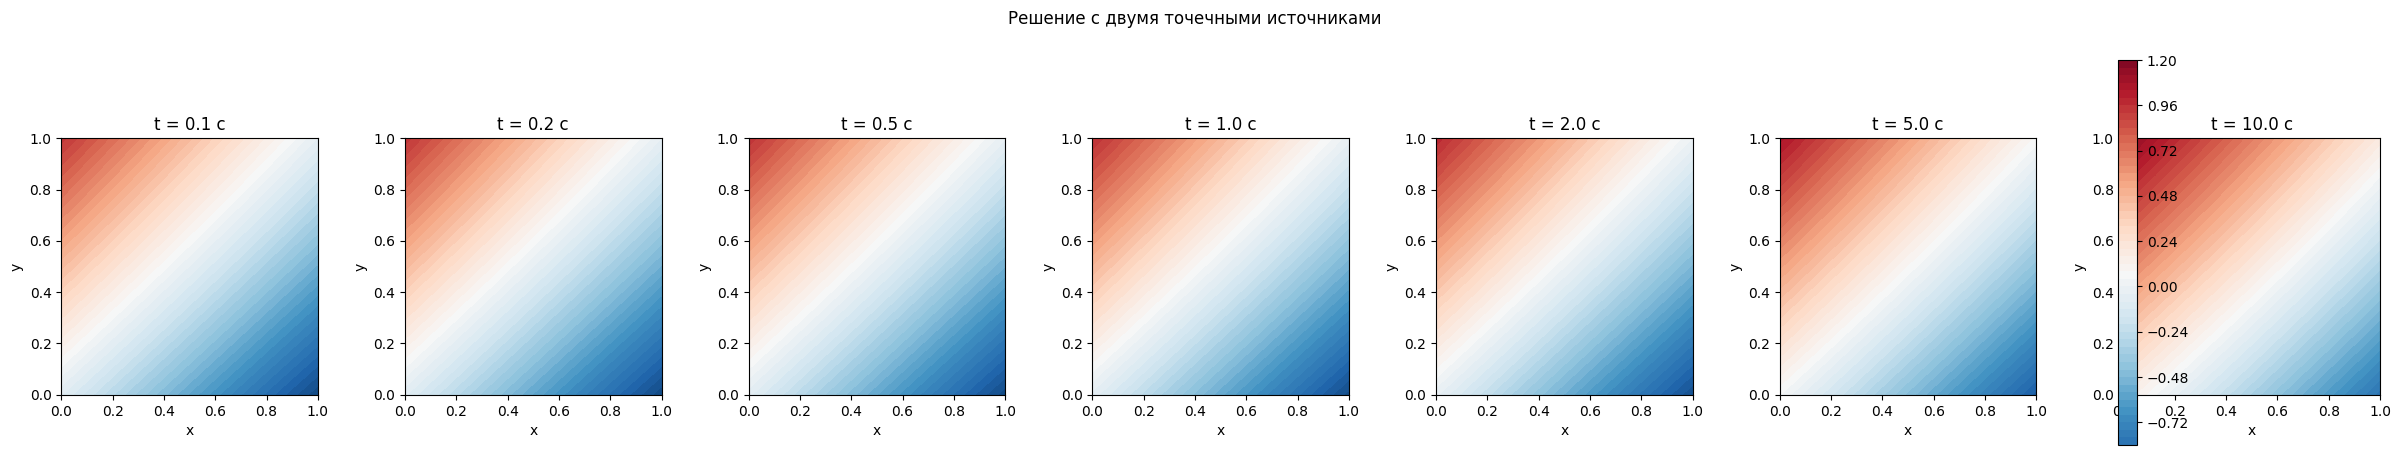

Время выполнения: 98.93 секунд


In [10]:
if __name__ == "__main__":
    start_time = time.time()

    model, data, losses = train_model()
    plot_training(losses)
    plot_solution(model)

    end_time = time.time()
    general_time = end_time - start_time

    print(f"Время выполнения: {general_time:.2f} секунд")